# Zero-Shot Person Re-Identification on PRW

End-to-end person search on the PRW dataset using only pretrained models — no task-specific training.

**Task**: given a query crop of a person, find that person across 6,112 whole-scene gallery frames.

**Pipeline**: detect all persons in gallery frames → extract visual features (DINOv2) → optionally enrich with text features (Gemma4 captions + CLIP) → cosine-similarity ranking.

| Config | Detector | Visual | Captions | Purpose |
|--------|----------|--------|----------|---------|
| A | YOLOv12 | DINOv2 | — | Visual-only baseline |
| B | YOLOv12 | DINOv2 | Gemma4 + CLIP | Add text enrichment |
| C | RF-DETR | DINOv2 | Gemma4 + CLIP | Swap detector |

**Before running**, install torch with your CUDA version:
```
uv add torch torchvision --index-url https://download.pytorch.org/whl/cu124
uv sync
```

In [1]:
import os
import re
import sys
import json
import warnings
from pathlib import Path
from typing import Optional

import numpy as np
from scipy.io import loadmat
from tqdm import tqdm
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
import torch

sys.path.insert(0, str(Path('.').resolve()))
from utils.eval_function import eval_search_prw

warnings.filterwarnings('ignore')

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Using device: {DEVICE}')

Using device: cuda


In [2]:
# ── Ablation Configuration ────────────────────────────────────────────────────
# Change RUN_CONFIG to switch ablation variant:
#   'A' → YOLOv12  + DINOv2           (visual-only baseline)
#   'B' → YOLOv12  + DINOv2 + Gemma4  (add text captions)
#   'C' → RF-DETR  + DINOv2 + Gemma4  (swap detector)
# ─────────────────────────────────────────────────────────────────────────────
RUN_CONFIG   = 'C'        # 'A' | 'B' | 'C'| 'D'
DET_THRESH   = 0.3        # eval detection threshold (detector uses 0.3 to keep cache loose. consider to use it to caption less detections.)
ALPHA        = 1        # text-feature weight; 0 → pure visual
DATASET_ROOT = 'dataset'

BATCH_DINO         = 32
BATCH_GEMMA        = 4
GEMMA_QUANTIZATION = None    # 4 → 4-bit NF4 | 8 → 8-bit | None → no quantization

CACHE_DIR = Path('cache')
CACHE_DIR.mkdir(exist_ok=True)

CONFIGS = {
    'A': {'detector': 'yolo12',  'caption': False},
    'B': {'detector': 'rfdetr',  'caption': False},
    'C': {'detector': 'yolo12',  'caption': True},
    'D': {'detector': 'rfdetr',  'caption': True},
}
cfg = CONFIGS[RUN_CONFIG]
print(f'Config {RUN_CONFIG}: {cfg}')

Config C: {'detector': 'yolo12', 'caption': True}


## 1. Dataset

Two splits:
- **Gallery** (6,112 test frames): whole-scene images; we detect persons in these.
- **Query** (2,057 images): pre-cropped person images from `dataset/query_box/`.

Annotation boxes are stored as `[x, y, w, h]` in the raw `.mat` files and `query_info.txt`; we convert to `[x1, y1, x2, y2]` throughout.

The query `img_name` is set to the **source frame** name (e.g. `c1s3_016471.jpg`) — this is required by `eval_search_prw` so it can exclude that frame from the gallery during evaluation. `get_image_path` constructs the actual crop path (`{pid}_{frame_base}.jpg` in `query_box/`).

In [3]:
def _cam_id_from_name(name: str) -> int:
    m = re.search(r'c(\d+)', name)
    if m is None:
        raise ValueError(f'Cannot parse camera ID from: {name}')
    return int(m.group(1))


def _xywh_to_xyxy(x: float, y: float, w: float, h: float) -> list:
    return [x, y, x + w, y + h]


class PRWDataset:
    """
    Wraps either the gallery or query split of PRW.

    annotations : list[dict]
        img_name  (str)          — bare filename; for queries this is the SOURCE frame
                                   name used by eval_search_prw for gallery exclusion
        cam_id    (int)          — camera 1–6
        pids      (ndarray|int)  — [N] int32 array (gallery) or scalar int (query)
        boxes     (ndarray)      — [N,4] float32 in x1,y1,x2,y2
    img_prefix : str — directory containing the images
    is_query   : bool — when True, get_image_path reconstructs the crop filename
    """

    def __init__(self, annotations: list, img_prefix: str, is_query: bool = False) -> None:
        self.annotations = annotations
        self.img_prefix  = img_prefix
        self.is_query    = is_query

    def __len__(self) -> int:
        return len(self.annotations)

    def get_image_path(self, idx: int) -> str:
        ann = self.annotations[idx]
        if self.is_query:
            # img_name = 'c1s3_016471.jpg'  →  crop = '479_c1s3_016471.jpg'
            frame_base = ann['img_name'].rsplit('.', 1)[0]
            return os.path.join(self.img_prefix, f"{ann['pids']}_{frame_base}.jpg")
        return os.path.join(self.img_prefix, ann['img_name'])

In [4]:
annotation_keys = ["box_new", "anno_file", "anno_previous"]

def build_gallery_dataset(dataset_root: str = 'dataset') -> PRWDataset:
    """
    Build gallery PRWDataset from the 6,112 test frames.
    Reads frame_test.mat and per-frame .mat annotation files.
    """
    root       = Path(dataset_root)
    test_arr   = loadmat(str(root / 'frame_test.mat'))['img_index_test'].ravel()
    test_names = [x.item() for x in test_arr]   # bare names without extension

    ann_dir     = root / 'annotations'
    annotations = []
    for name in tqdm(test_names, desc='Loading gallery annotations'):
        mat     = loadmat(str(ann_dir / f'{name}.jpg.mat'))

        key_error = True # to handle different annotation keys
        i = 0
        while(key_error):
            try:
                box_new = mat[annotation_keys[i]]                         # [N, 5]: pid, x, y, w, h
                key_error = False
            except:
                i += 1

        pids    = box_new[:, 0].astype(np.int32)
        boxes   = np.stack(
            [box_new[:, 1],
             box_new[:, 2],
             box_new[:, 1] + box_new[:, 3],
             box_new[:, 2] + box_new[:, 4]],
            axis=1,
        ).astype(np.float32)
        annotations.append({
            'img_name': f'{name}.jpg',
            'cam_id':   _cam_id_from_name(name),
            'pids':     pids,
            'boxes':    boxes,
        })

    return PRWDataset(annotations, str((root / 'frames').resolve()), is_query=False)


def build_query_dataset(dataset_root: str = 'dataset') -> PRWDataset:
    """
    Build query PRWDataset from query_info.txt (2,057 queries).
    Line format: pid x y w h frame_name
    """
    root        = Path(dataset_root)
    annotations = []
    with open(root / 'query_info.txt') as f:
        for line in f:
            parts      = line.strip().split()
            pid        = int(parts[0])
            x, y, w, h = float(parts[1]), float(parts[2]), float(parts[3]), float(parts[4])
            frame_name = parts[5]
            annotations.append({
                'img_name': f'{frame_name}.jpg',   # source frame name — for eval exclusion
                'cam_id':   _cam_id_from_name(frame_name),
                'pids':     pid,                   # scalar int
                'boxes':    np.array([_xywh_to_xyxy(x, y, w, h)], dtype=np.float32),
            })

    return PRWDataset(annotations, str((root / 'query_box').resolve()), is_query=True)

In [5]:
gallery_dataset = build_gallery_dataset(DATASET_ROOT)
query_dataset   = build_query_dataset(DATASET_ROOT)

print(f'Gallery frames : {len(gallery_dataset)}')   # expected: 6112
print(f'Query images   : {len(query_dataset)}')      # expected: 2057

g0 = gallery_dataset.annotations[0]
q0 = query_dataset.annotations[0]
print(f'\nGallery[0]: {g0["img_name"]}, cam={g0["cam_id"]}, '
      f'n_persons={len(g0["pids"])}, boxes.shape={g0["boxes"].shape}')
print(f'Query[0]  : {q0["img_name"]}, cam={q0["cam_id"]}, '
      f'pid={q0["pids"]}, box={q0["boxes"]}')
print(f'Query[0] crop path: {query_dataset.get_image_path(0)}')

Loading gallery annotations:  19%|█▉        | 1175/6112 [00:00<00:00, 11742.06it/s]

Loading gallery annotations: 100%|██████████| 6112/6112 [00:00<00:00, 11694.39it/s]

Gallery frames : 6112
Query images   : 2057

Gallery[0]: c1s2_071096.jpg, cam=1, n_persons=4, boxes.shape=(4, 4)
Query[0]  : c1s3_016471.jpg, cam=1, pid=479, box=[[1750.0896  407.541  1836.3962  624.474 ]]
Query[0] crop path: /home/leonardo/github/ds-dashboard/dataset/query_box/479_c1s3_016471.jpg


## 2. Detectors

All detectors share the same interface: `detect_frame(path) → ndarray[n_det, 5]` where columns are `[x1, y1, x2, y2, score]`.

Detection uses a **loose confidence threshold (0.3)** so borderline detections are preserved in the cache. `eval_search_prw` applies `DET_THRESH=0.5` as a second filter — this lets us sweep `DET_THRESH` without re-running the expensive detection step.

In [6]:
class BaseDetector:
    def detect_frame(self, img_path: str) -> np.ndarray:
        """Return [n_det, 5] float32 (x1,y1,x2,y2,score), or [0,5] if none found."""
        raise NotImplementedError

    def detect_batch(self, img_paths: list, desc: str = 'Detecting') -> list:
        return [self.detect_frame(p) for p in tqdm(img_paths, desc=desc, unit='frame')]


class YOLODetector(BaseDetector):
    """YOLOv12 person detector via ultralytics. Downloads weights on first call."""

    _PERSON_CLS = 0   # YOLO class index for 'person'

    def __init__(self, model_name: str = 'yolo12s.pt', conf_thresh: float = 0.3,
                 device: str = DEVICE) -> None:
        from ultralytics import YOLO
        self.model       = YOLO(model_name)
        self.conf_thresh = conf_thresh
        self.device      = device

    def detect_frame(self, img_path: str) -> np.ndarray:
        results = self.model(
            img_path,
            classes=[self._PERSON_CLS],
            conf=self.conf_thresh,
            verbose=False,
            device=self.device,
        )
        r = results[0]
        if len(r.boxes) == 0:
            return np.zeros((0, 5), dtype=np.float32)
        boxes  = r.boxes.xyxy.cpu().numpy()           # [N, 4]
        scores = r.boxes.conf.cpu().numpy()[:, None]  # [N, 1]
        return np.concatenate([boxes, scores], axis=1).astype(np.float32)
    

class RFDETRDetector(BaseDetector):
    """RF-DETR person detector (Roboflow). Requires: uv add rfdetr supervision."""

    from rfdetr.assets.coco_classes import COCO_CLASSES
    _PERSON_CLS = 1 # [k for k,v in COCO_CLASSES.items() if v == "person"][0] 

    def __init__(self, conf_thresh: float = 0.5) -> None:
        from rfdetr import RFDETRBase
        self.model       = RFDETRBase()
        self.model.optimize_for_inference() # actually not affecting that much!
        self.conf_thresh = conf_thresh

    def detect_frame(self, img_path: str) -> np.ndarray:
        img  = Image.open(img_path).convert('RGB')
        dets = self.model.predict(img, threshold=self.conf_thresh)
        # dets is supervision.Detections: .xyxy [N,4], .confidence [N], .class_id [N]
        mask = dets.class_id == self._PERSON_CLS
        if mask.sum() == 0:
            return np.zeros((0, 5), dtype=np.float32)
        boxes  = dets.xyxy[mask]
        scores = dets.confidence[mask][:, None]
        return np.concatenate([boxes, scores], axis=1).astype(np.float32)

In [7]:
def build_detector(config: dict) -> BaseDetector:
    if config['detector'] == 'yolo12':
        return YOLODetector(model_name='yolo12s.pt', device=DEVICE)
    elif config['detector'] == 'rfdetr':
        return RFDETRDetector()
    raise ValueError(f"Unknown detector: {config['detector']}")

In [8]:
detector = build_detector(cfg)

In [9]:
detector.model.optimize_for_inference()

AttributeError: 'DetectionModel' object has no attribute 'optimize_for_inference'

In [35]:
from rfdetr.assets.coco_classes import COCO_CLASSES
import supervision as sv

img_path = "./dataset/frames/c1s1_000451.jpg"
img  = Image.open(img_path).convert('RGB')
detections = detector.model.predict(img, threshold=0.5)
labels = [f"{COCO_CLASSES[class_id]}" for class_id in detections.class_id]
id_labels = [(f"{COCO_CLASSES[class_id]}", class_id) for class_id in detections.class_id]

In [36]:
id_labels

[('person', 1),
 ('person', 1),
 ('person', 1),
 ('bicycle', 2),
 ('bicycle', 2),
 ('bicycle', 2),
 ('person', 1),
 ('bicycle', 2),
 ('backpack', 27),
 ('bicycle', 2),
 ('bicycle', 2),
 ('bicycle', 2),
 ('bicycle', 2),
 ('bicycle', 2)]

In [37]:
annotated_image = sv.BoxAnnotator().annotate(detections.metadata["source_image"], detections)
annotated_image = sv.LabelAnnotator().annotate(annotated_image, detections, labels)

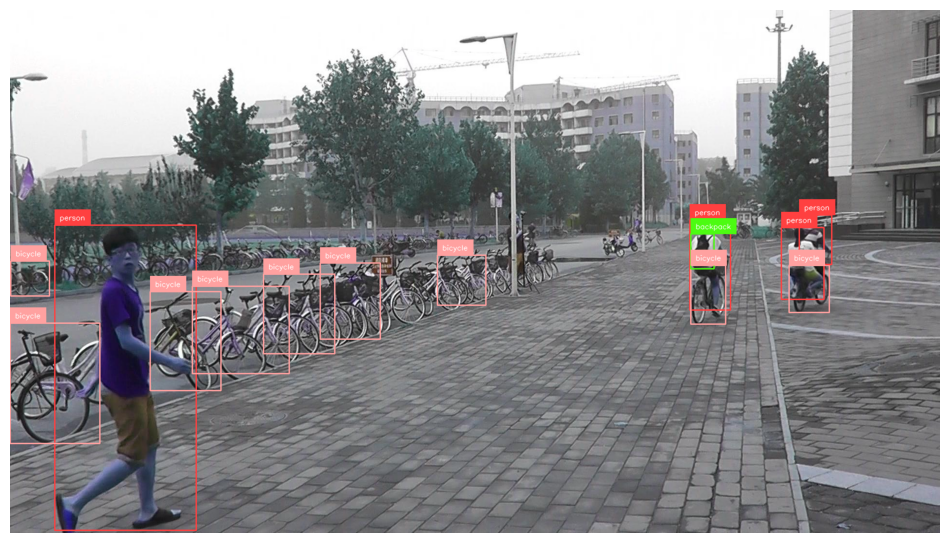

In [38]:
sv.plot_image(annotated_image)

## 3. Visual Encoder — DINO

DINOv2-large (ViT-L/14) encodes person crops to 1024-dim CLS token features. These are **L2-normalized** so that dot product = cosine similarity, matching the expectation of `eval_search_prw`.

DINOv2 is preferred over CLIP for the visual component because its features are optimized for fine-grained visual discriminability (patch-level structural features) rather than semantic category matching.

In [ ]:
class DINOv2Encoder:
    """DINOv2-large visual encoder. Outputs L2-normalized 1024-dim CLS features."""

    def __init__(self, model_name: str = 'facebook/dinov2-large',
                 batch_size: int = BATCH_DINO, device: str = DEVICE) -> None:
        from transformers import AutoImageProcessor, AutoModel
        self.processor  = AutoImageProcessor.from_pretrained(model_name)
        self.model      = AutoModel.from_pretrained(model_name).to(device).eval()
        self.batch_size = batch_size
        self.device     = device
        self.feat_dim   = 1024

    @torch.no_grad()
    def encode_images(self, images: list) -> np.ndarray:
        """
        Encode a list of PIL images to L2-normalized [N, 1024] float32.
        Processes in batches of self.batch_size to bound GPU memory.
        """
        all_feats = []
        for i in range(0, len(images), self.batch_size):
            batch  = images[i : i + self.batch_size]
            inputs = self.processor(images=batch, return_tensors='pt').to(self.device)
            out    = self.model(**inputs)
            # cls    = out.last_hidden_state[:, 0, :].cpu().float().numpy()  # CLS token
            pooled_patches = out.last_hidden_state[:, 1:, :].mean(dim=1).cpu().float().numpy()  # (B, dim)
            cls = out.pooler_output.cpu().float().numpy() # CLS token
            # all_feats.append(cls)
            all_feats.append(pooled_patches)
        feats = np.concatenate(all_feats, axis=0)            # [N, 1024]
        norms = np.linalg.norm(feats, axis=1, keepdims=True).clip(min=1e-8)
        return (feats / norms).astype(np.float32)

    def encode_crops_from_paths(self, paths: list, desc: str = 'DINOv2') -> list:
        """Load images from disk, encode, return list of [D] L2-normalized vectors."""
        images = [Image.open(p).convert('RGB')
                  for p in tqdm(paths, desc=f'Loading ({desc})')]
        feats  = self.encode_images(images)                  # [N, D]
        return [feats[i] for i in range(len(feats))]


class DINOv3Encoder:
    """DINOv3-large visual encoder. Outputs L2-normalized 1024-dim CLS features."""

    def __init__(self, model_name: str = 'facebook/dinov3-vitl16-pretrain-lvd1689m',
                 batch_size: int = BATCH_DINO, device: str = DEVICE) -> None:
        from transformers import AutoImageProcessor, AutoModel
        self.processor  = AutoImageProcessor.from_pretrained(model_name)
        self.model      = AutoModel.from_pretrained(model_name).to(device).eval()
        self.batch_size = batch_size
        self.device     = device
        self.feat_dim   = 1024

    @torch.no_grad()
    def encode_images(self, images: list) -> np.ndarray:
        """
        Encode a list of PIL images to L2-normalized [N, 1024] float32.
        Processes in batches of self.batch_size to bound GPU memory.
        """
        all_feats = []
        for i in range(0, len(images), self.batch_size):
            batch  = images[i : i + self.batch_size]
            inputs = self.processor(images=batch, return_tensors='pt').to(self.device)
            out    = self.model(**inputs)
            # cls    = out.last_hidden_state[:, 0, :].cpu().float().numpy()  # CLS token
            pooled_output = out.pooler_output.cpu().float().numpy() # pooler output
            # all_feats.append(cls)
            all_feats.append(pooled_output)
        feats = np.concatenate(all_feats, axis=0)            # [N, 1024]
        norms = np.linalg.norm(feats, axis=1, keepdims=True).clip(min=1e-8)
        return (feats / norms).astype(np.float32)

    def encode_crops_from_paths(self, paths: list, desc: str = 'DINOv3') -> list:
        """Load images from disk, encode, return list of [D] L2-normalized vectors."""
        images = [Image.open(p).convert('RGB')
                  for p in tqdm(paths, desc=f'Loading ({desc})')]
        feats  = self.encode_images(images)                  # [N, D]
        return [feats[i] for i in range(len(feats))]

## 4. Caption Generator & Text Encoder

**Idea**: use Gemma4 to generate a one-sentence appearance description per person crop (*"woman in red jacket, dark jeans, black backpack"*). Encode these captions with CLIP's text encoder, then fuse with DINOv2 visual features.

Text descriptions are **camera-invariant** in a way that pixel features are not: clothing color is the same description under different lighting conditions. This provides a complementary signal for cross-camera matching.

Captions are generated **once per crop** (O(total detections)), not per query-gallery pair — making this computationally tractable.

The `alpha` hyperparameter controls the text contribution:
- `alpha=0` → pure visual (same as Config A)
- `alpha=1` → equal weight to text features
- Alpha sweep in Section 8 finds the optimal value.

In [10]:
class GemmaCaptioner:
    """
    Generates appearance captions for person crops using google/gemma-4-e2b-it.

    Uses AutoModelForImageTextToText + apply_chat_template (standard HF multimodal API).
    Captions are cached to disk — this is the most expensive stage (~hours on GPU).

    quantization : int | None
        4  → 4-bit NF4 (bitsandbytes, lowest VRAM, slight quality drop)
        8  → 8-bit (bitsandbytes, moderate VRAM, minimal quality drop)
        None → bfloat16 full-precision (best quality, highest VRAM)
    """

    PROMPT = (
        'Describe this person\'s appearance in one sentence. '
        'Focus on: gender, clothing colors, clothing type (shirt/jacket/dress/coat), '
        'footwear color, and any distinctive accessories (bag, hat, umbrella). '
        'Be concise and specific.'
    )

    def __init__(self, model_name: str = 'google/gemma-4-e2b-it',
                 quantization: Optional[int] = None,
                 device: str = DEVICE) -> None:
        from transformers import AutoProcessor, AutoModelForImageTextToText, BitsAndBytesConfig

        self.processor = AutoProcessor.from_pretrained(model_name)

        bnb_config = None
        if quantization == 4:
            bnb_config = BitsAndBytesConfig(
                load_in_4bit=True,
                bnb_4bit_quant_type='nf4',
                bnb_4bit_use_double_quant=True,
                bnb_4bit_compute_dtype=torch.bfloat16,
            )
        elif quantization == 8:
            bnb_config = BitsAndBytesConfig(load_in_8bit=True)
        elif quantization is not None:
            raise ValueError(
                f'Unsupported quantization: {quantization!r}. Use 4, 8, or None.'
            )

        model_kwargs = {'device_map': 'auto'}
        if bnb_config is not None:
            model_kwargs['quantization_config'] = bnb_config
        else:
            model_kwargs['torch_dtype'] = torch.bfloat16

        self.model = AutoModelForImageTextToText.from_pretrained(
            model_name, **model_kwargs
        ).eval()

    @torch.no_grad()
    def caption_single(self, image: Image.Image) -> str:
        messages = [
            {
                'role': 'user',
                'content': [
                    {'type': 'image'},              # placeholder; image passed to processor
                    {'type': 'text', 'text': self.PROMPT},
                ],
            }
        ]
        text   = self.processor.apply_chat_template(
            messages, tokenize=False, add_generation_prompt=True
        )
        inputs = self.processor(
            text=text, images=[image], return_tensors='pt'
        ).to(self.model.device)
        n_in   = inputs['input_ids'].shape[1]
        out    = self.model.generate(**inputs, max_new_tokens=60, do_sample=False)
        return self.processor.decode(out[0][n_in:], skip_special_tokens=True).strip()

    def caption_batch(self, images: list, batch_size: int = BATCH_GEMMA,
                      desc: str = 'Gemma captioning') -> list:
        captions = []
        for img in tqdm(images, desc=desc):
            try:
                captions.append(self.caption_single(img))
            except Exception:
                captions.append('')   # fallback for degenerate crops
        return captions

In [11]:
class CLIPTextEncoder:
    """CLIP-ViT-L/14 text encoder. Outputs L2-normalized 768-dim text features."""

    def __init__(self, model_name: str = 'openai/clip-vit-large-patch14',
                 batch_size: int = 64, device: str = DEVICE) -> None:
        from transformers import CLIPModel, CLIPTokenizer
        self.tokenizer  = CLIPTokenizer.from_pretrained(model_name)
        self.model      = CLIPModel.from_pretrained(model_name).to(device).eval()
        self.batch_size = batch_size
        self.device     = device
        self.feat_dim   = 768

    @torch.no_grad()
    def encode_texts(self, captions: list) -> np.ndarray:
        """Return L2-normalized [N, 768] float32 array."""
        all_feats = []
        for i in range(0, len(captions), self.batch_size):
            batch  = captions[i : i + self.batch_size]
            inputs = self.tokenizer(
                batch, padding=True, truncation=True, max_length=77, return_tensors='pt'
            ).to(self.device)
            feats  = self.model.get_text_features(**inputs).pooler_output # we take the pool output layer, representing the encoding of the whole sentence
            feats = feats.cpu().float().numpy()
            all_feats.append(feats)
        feats = np.concatenate(all_feats, axis=0)            # [N, 768]
        norms = np.linalg.norm(feats, axis=1, keepdims=True).clip(min=1e-8)
        return (feats / norms).astype(np.float32)


def fuse_features(visual_feats: np.ndarray, text_feats: np.ndarray,
                  alpha: float = ALPHA) -> np.ndarray:
    """
    Fuse DINOv2 visual and CLIP text features.

    Result: L2_normalize(concat(visual, alpha * text))
    Supports both 1D (single vector) and 2D (batch) inputs.
    alpha=0 zeroes out text but keeps the same output dimension — use
    gallery_text_feats=None in build_final_gallery_feats to skip fusion entirely.
    """
    scalar = visual_feats.ndim == 1
    if scalar:
        visual_feats = visual_feats[None]
        text_feats   = text_feats[None]

    # normalize independently first
    visual_norm = visual_feats / np.linalg.norm(visual_feats, axis=1, keepdims=True).clip(min=1e-8)
    text_norm   = text_feats  / np.linalg.norm(text_feats,   axis=1, keepdims=True).clip(min=1e-8)

    # then weight and concat
    fused = np.concatenate([visual_norm, alpha * text_norm], axis=1).astype(np.float32)
    norms = np.linalg.norm(fused, axis=1, keepdims=True).clip(min=1e-8)

    # final normalization
    fused = fused / norms
    return fused[0] if scalar else fused

## 5. Gallery Processing

Five stages, each with disk caching (named by `RUN_CONFIG` to avoid cross-contamination):

1. **Detection** — run detector on all 6,112 frames → `[n_det, 5]` per frame
2. **Visual features** — DINOv2 on each detected crop → `[n_det, 1024]` per frame
3. **Captions** — Gemma4 description per crop → `list[list[str]]` (Configs B/C only)
4. **Text features** — CLIP text encoder on captions → `[n_det, 768]` per frame (B/C only)
5. **Fusion** — `L2_normalize(concat(visual, alpha * text))` per frame

In [12]:
def _crop_persons(frame: Image.Image, dets: np.ndarray) -> list:
    """Crop detected bounding boxes from a PIL frame, clipping to image bounds."""
    W, H  = frame.size
    crops = []
    for x1, y1, x2, y2, _ in dets:
        x1c, y1c = max(0, int(x1)), max(0, int(y1))
        x2c, y2c = min(W, int(x2)), min(H, int(y2))
        if x2c > x1c and y2c > y1c:
            crops.append(frame.crop((x1c, y1c, x2c, y2c)))
        else:
            crops.append(Image.new('RGB', (64, 128)))   # degenerate bbox fallback
    return crops


def run_gallery_detection(gallery_dataset: PRWDataset, detector: BaseDetector,
                          cache_path: Path, force: bool = False) -> list:
    """
    Detect persons in all gallery frames. Returns list of [n_det, 5] float32 arrays.
    Caches results as a numpy object array; loads from cache if available.
    """
    if cache_path.exists() and not force:
        print(f'Loading detections from cache: {cache_path}')
        return list(np.load(str(cache_path), allow_pickle=True))

    img_paths    = [gallery_dataset.get_image_path(i) for i in range(len(gallery_dataset))]
    gallery_dets = detector.detect_batch(img_paths, desc='Detecting gallery')

    arr = np.empty(len(gallery_dets), dtype=object)
    for i, d in enumerate(gallery_dets):
        arr[i] = d if d.shape[0] > 0 else np.zeros((0, 5), dtype=np.float32)
    np.save(str(cache_path), arr)
    print(f'Saved detections \u2192 {cache_path}')
    return list(arr)

In [13]:
def run_gallery_visual_features(gallery_dataset: PRWDataset, gallery_dets: list,
                                encoder: DINOv2Encoder, cache_path: Path,
                                force: bool = False) -> list:
    """
    Extract DINOv2 CLS features for every detected person crop.
    Returns list of [n_det, D] L2-normalized float32 arrays; [0, D] for empty frames.
    """
    if cache_path.exists() and not force:
        print(f'Loading visual features from cache: {cache_path}')
        return list(np.load(str(cache_path), allow_pickle=True))

    D = encoder.feat_dim
    gallery_feats = []
    for i in tqdm(range(len(gallery_dataset)), desc='Visual features (gallery)'):
        dets = gallery_dets[i]
        if dets.shape[0] == 0:
            gallery_feats.append(np.zeros((0, D), dtype=np.float32))
            continue
        frame = Image.open(gallery_dataset.get_image_path(i)).convert('RGB')
        crops = _crop_persons(frame, dets)
        gallery_feats.append(encoder.encode_images(crops))   # [n_det, D]

    arr = np.empty(len(gallery_feats), dtype=object)
    for i, f in enumerate(gallery_feats):
        arr[i] = f
    np.save(str(cache_path), arr)
    print(f'Saved visual features \u2192 {cache_path}')
    return list(arr)

In [14]:
def run_gallery_captions(gallery_dataset: PRWDataset, gallery_dets: list,
                         captioner: GemmaCaptioner, cache_path: Path,
                         force: bool = False) -> list:
    """
    Generate Gemma4 captions for all detected person crops.
    Returns list[list[str]]: outer = frames, inner = one caption per detection.
    Cached as JSON — this is the most time-consuming stage.
    """
    if cache_path.exists() and not force:
        print(f'Loading captions from cache: {cache_path}')
        with open(cache_path) as f:
            return json.load(f)

    gallery_captions = []
    for i in tqdm(range(len(gallery_dataset)), desc='Gemma captioning (gallery)'):
        dets = gallery_dets[i]
        if dets.shape[0] == 0:
            gallery_captions.append([])
            continue
        frame = Image.open(gallery_dataset.get_image_path(i)).convert('RGB')
        crops = _crop_persons(frame, dets)
        gallery_captions.append(captioner.caption_batch(crops, desc=''))

    with open(cache_path, 'w') as f:
        json.dump(gallery_captions, f)
    print(f'Saved captions \u2192 {cache_path}')
    return gallery_captions


def run_gallery_text_features(gallery_captions: list, text_encoder: CLIPTextEncoder,
                              cache_path: Path, force: bool = False) -> list:
    """
    CLIP-encode gallery captions to L2-normalized text features.
    Returns list of [n_det, D_text] float32 arrays; [0, D_text] for empty frames.
    """
    D_text = text_encoder.feat_dim
    if cache_path.exists() and not force:
        print(f'Loading text features from cache: {cache_path}')
        return list(np.load(str(cache_path), allow_pickle=True))

    gallery_text_feats = []
    for caps in tqdm(gallery_captions, desc='CLIP text features (gallery)'):
        if len(caps) == 0:
            gallery_text_feats.append(np.zeros((0, D_text), dtype=np.float32))
        else:
            gallery_text_feats.append(text_encoder.encode_texts(caps))

    arr = np.empty(len(gallery_text_feats), dtype=object)
    for i, f in enumerate(gallery_text_feats):
        arr[i] = f
    np.save(str(cache_path), arr)
    print(f'Saved text features \u2192 {cache_path}')
    return list(arr)


def build_final_gallery_feats(gallery_vis_feats: list,
                              gallery_text_feats: Optional[list],
                              alpha: float = ALPHA) -> list:
    """
    Fuse visual and text features per frame.
    When gallery_text_feats is None (Config A), returns visual features unchanged.
    Otherwise always fuses (even at alpha=0) to keep dims consistent with queries.
    """
    if gallery_text_feats is None:
        return gallery_vis_feats
    fused = []
    for vis, txt in zip(gallery_vis_feats, gallery_text_feats):
        if vis.shape[0] == 0:
            fused.append(np.zeros((0, vis.shape[1] + txt.shape[1]), dtype=np.float32))
        else:
            fused.append(fuse_features(vis, txt, alpha))
    return fused

In [15]:
# ── Cache paths (named by config to prevent cross-contamination) ──────────────
DETS_CACHE = CACHE_DIR / f'gallery_dets_{RUN_CONFIG}.npy'
VIS_CACHE  = CACHE_DIR / f'gallery_vis_{RUN_CONFIG}.npy'
CAPS_CACHE = CACHE_DIR / f'gallery_caps_{RUN_CONFIG}.json'
TXT_CACHE  = CACHE_DIR / f'gallery_txt_{RUN_CONFIG}.npy'

# ── Instantiate models ────────────────────────────────────────────────────────
detector = build_detector(cfg)
dino_enc = DINOv2Encoder(device=DEVICE)
# dino_enc = DINOv3Encoder(device=DEVICE)

# ── Stage 1: Detection ────────────────────────────────────────────────────────
gallery_dets = run_gallery_detection(gallery_dataset, detector, DETS_CACHE)

# ── Stage 2: Visual features ──────────────────────────────────────────────────
gallery_vis_feats = run_gallery_visual_features(
    gallery_dataset, gallery_dets, dino_enc, VIS_CACHE
)

# ── Stages 3 & 4: Captions + text features (Configs B & C only) ───────────────
gallery_text_feats = None
if cfg['caption']:
    captioner    = GemmaCaptioner(device=DEVICE, quantization=GEMMA_QUANTIZATION)
    text_encoder = CLIPTextEncoder(device=DEVICE)
    gallery_caps = run_gallery_captions(
        gallery_dataset, gallery_dets, captioner, CAPS_CACHE
    )
    gallery_text_feats = run_gallery_text_features(gallery_caps, text_encoder, TXT_CACHE)

# ── Stage 5: Fuse ─────────────────────────────────────────────────────────────
gallery_feats = build_final_gallery_feats(gallery_vis_feats, gallery_text_feats, ALPHA)

sample = next(f for f in gallery_feats if f.shape[0] > 0)
print(f'gallery_feats sample shape: {sample.shape}')

Loading weights: 100%|██████████| 439/439 [00:00<00:00, 20404.47it/s]


Loading detections from cache: cache/gallery_dets_C.npy


Visual features (gallery):   0%|          | 0/6112 [00:00<?, ?it/s]


TypeError: can't convert cuda:0 device type tensor to numpy. Use Tensor.cpu() to copy the tensor to host memory first.

In [16]:
n = 0
for x in gallery_dets:
    n += len(x)
print(f"detected persons:       {n}")
print(f"avg persons per frame:  {n/len(gallery_dets)}")

detected persons:       23897
avg persons per frame:  3.9098494764397906


## 6. Query Processing

Query images are pre-cropped in `dataset/query_box/` — no detection step needed. We extract the same features as for gallery crops and fuse with the same `alpha`.

Note: `img_name` in query annotations is the **source frame** name (used by eval for exclusion), but `get_image_path` transparently returns the crop path.

In [17]:
Q_VIS_CACHE  = CACHE_DIR / f'query_vis_{RUN_CONFIG}.npy'
Q_CAPS_CACHE = CACHE_DIR / f'query_caps_{RUN_CONFIG}.json'
Q_TXT_CACHE  = CACHE_DIR / f'query_txt_{RUN_CONFIG}.npy'


def run_query_features(query_dataset: PRWDataset, encoder: DINOv2Encoder,
                       captioner: Optional[GemmaCaptioner],
                       text_encoder: Optional[CLIPTextEncoder],
                       alpha: float,
                       vis_cache: Path, caps_cache: Path, txt_cache: Path,
                       force: bool = False) -> list:
    """
    Extract final L2-normalized features for all 2,057 query crops.
    Returns list of M [D] float32 vectors aligned with query_dataset.annotations.
    When captioner is None (Config A), returns visual-only features.
    Otherwise always fuses (even alpha=0) to keep dims consistent with gallery.
    """
    # ── Visual features ───────────────────────────────────────────────────────
    if vis_cache.exists() and not force:
        print(f'Loading query visual features from cache: {vis_cache}')
        vis_feats = np.load(str(vis_cache))                   # [M, D_v]
    else:
        paths     = [query_dataset.get_image_path(i) for i in range(len(query_dataset))]
        vis_list  = encoder.encode_crops_from_paths(paths, desc='DINOv2 (queries)')
        vis_feats = np.stack(vis_list, axis=0)                # [M, D_v]
        np.save(str(vis_cache), vis_feats)
        print(f'Saved query visual features \u2192 {vis_cache}')

    if captioner is None:
        return [vis_feats[i] for i in range(len(vis_feats))]

    # ── Captions ──────────────────────────────────────────────────────────────
    if caps_cache.exists() and not force:
        print(f'Loading query captions from cache: {caps_cache}')
        with open(caps_cache) as f:
            captions = json.load(f)
    else:
        images   = [Image.open(query_dataset.get_image_path(i)).convert('RGB')
                    for i in range(len(query_dataset))]
        captions = captioner.caption_batch(images, desc='Gemma captioning (queries)')
        with open(caps_cache, 'w') as f:
            json.dump(captions, f)
        print(f'Saved query captions \u2192 {caps_cache}')

    # ── Text features ─────────────────────────────────────────────────────────
    if txt_cache.exists() and not force:
        print(f'Loading query text features from cache: {txt_cache}')
        txt_feats = np.load(str(txt_cache))                   # [M, D_t]
    else:
        txt_feats = text_encoder.encode_texts(captions)
        np.save(str(txt_cache), txt_feats)
        print(f'Saved query text features \u2192 {txt_cache}')

    # ── Fuse (always fuse when captioner present, for consistent dims) ────────
    fused = fuse_features(vis_feats, txt_feats, alpha)        # [M, D_v + D_t]
    return [fused[i] for i in range(len(fused))]

In [18]:
query_box_feats = run_query_features(
    query_dataset,
    encoder=dino_enc,
    captioner=captioner if cfg['caption'] else None,
    text_encoder=text_encoder if cfg['caption'] else None,
    alpha=ALPHA,
    vis_cache=Q_VIS_CACHE,
    caps_cache=Q_CAPS_CACHE,
    txt_cache=Q_TXT_CACHE,
)
print(f'query_box_feats[0].shape = {query_box_feats[0].shape}')
print(f'Total queries: {len(query_box_feats)}')

Loading (DINOv2 (queries)): 100%|██████████| 2057/2057 [00:00<00:00, 5283.16it/s]


Saved query visual features → cache/query_vis_C.npy
Loading query captions from cache: cache/query_caps_C.json
Loading query text features from cache: cache/query_txt_C.npy
query_box_feats[0].shape = (1792,)
Total queries: 2057


## 7. Evaluation

`eval_search_prw` evaluates person search performance:
- For each query, ranks all gallery detections by cosine similarity to the query feature
- Labels a detection as TP if IoU ≥ threshold with the ground-truth box for that person
- Computes per-query Average Precision, scaled by detection recall rate (penalizes missed detections)
- Returns **mAP** and **top-1 accuracy**

In [19]:
print(f"\n{'=' * 60}")
print(f'Config {RUN_CONFIG} | det_thresh={DET_THRESH} | alpha={ALPHA}')
print('=' * 60)

results = eval_search_prw(
    gallery_dataset=gallery_dataset,
    query_dataset=query_dataset,
    gallery_dets=gallery_dets,
    gallery_feats=gallery_feats,
    query_box_feats=query_box_feats,
    det_thresh=DET_THRESH,
)

# Save scalar metrics (strip non-serialisable numpy arrays)
out = {k: v.tolist() if isinstance(v, np.ndarray) else v
       for k, v in results.items() if k != 'results'}
results_path = CACHE_DIR / f'results_{RUN_CONFIG}_alpha{ALPHA}.json'
with open(results_path, 'w') as f:
    json.dump(out, f, indent=2)
print(f'\nResults saved \u2192 {results_path}')


Config C | det_thresh=0.3 | alpha=1


search ranking:
  mAP = 7.56%
  top- 1 = 40.30%
recall rate: 0.9375

Results saved → cache/results_C_alpha1.json


In [ ]:
# ============================================================
# Config C | DINOV3
# ============================================================
# search ranking:
#   mAP = 7.18%
#   top- 1 = 41.23%
# recall rate: 0.9375

# Results saved → cache/results_C_alpha1.json

# ============================================================
# Config C | DINOV2
# ============================================================
# search ranking:
#   mAP = 7.56%
#   top- 1 = 40.30%
# recall rate: 0.9375

# Results saved → cache/results_C_alpha1.json

In [ ]:
# ============================================================
# DINOV2
# ============================================================
# search ranking:
#   mAP = 2.87%
#   top- 1 = 22.80%
# recall rate: 1.0

# Results saved → cache/results_B_alpha0.json

# ============================================================
# DINOV3
# ============================================================
# search ranking:
#   mAP = 2.82%
#   top- 1 = 25.47%
# recall rate: 1.0

# Results saved → cache/results_B_alpha0.json

In [ ]:
# ============================================================
# Config B | det_thresh=0.5 | alpha=0.5
# ============================================================
# search ranking:
#   mAP = 2.87%
#   top- 1 = 22.80%
# recall rate: 1.0

# Results saved → cache/results_B_alpha0.5.json

In [ ]:
# ============================================================
# Config B | det_thresh=0.3 | alpha=1
# ============================================================
# search ranking:
#   mAP = 7.56%
#   top- 1 = 40.30%
# recall rate: 0.9375

# Results saved → cache/results_B_alpha1.json

## 8. Alpha Sweep (Configs B & C only)

Sweep the `alpha` text-feature weight to find the optimal balance between DINOv2 visual features and CLIP text features. Reuses cached visual and text feature arrays — no model re-runs needed.

In [ ]:
def run_alpha_sweep(gallery_vis_feats: list, gallery_text_feats: list,
                    gallery_dets: list, gallery_dataset: PRWDataset,
                    query_dataset: PRWDataset, q_vis: np.ndarray, q_text: np.ndarray,
                    alphas: list, det_thresh: float = DET_THRESH) -> dict:
    """
    Sweep alpha values and return {alpha: {'mAP': ..., 'top1': ...}}.
    For each alpha, fuses cached features and runs eval_search_prw.
    """
    sweep = {}
    for alpha in alphas:
        print(f'\n--- alpha = {alpha} ---')
        gf     = build_final_gallery_feats(gallery_vis_feats, gallery_text_feats, alpha)
        q_fuse = fuse_features(q_vis, q_text, alpha)       # [M, D_v + D_t]
        qf     = [q_fuse[i] for i in range(len(q_fuse))]
        res    = eval_search_prw(
            gallery_dataset, query_dataset, gallery_dets, gf, qf, det_thresh
        )
        sweep[alpha] = {'mAP': float(res['mAP']), 'top1': float(res['accs'][0])}
    return sweep

In [ ]:
if cfg['caption'] and gallery_text_feats is not None:
    ALPHAS = [0.0, 0.1, 0.2, 0.3, 0.5, 0.7, 1.0]

    q_vis  = np.load(str(Q_VIS_CACHE))
    q_text = np.load(str(Q_TXT_CACHE))

    sweep = run_alpha_sweep(
        gallery_vis_feats, gallery_text_feats,
        gallery_dets, gallery_dataset, query_dataset,
        q_vis, q_text, ALPHAS,
    )

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
    ax1.plot(ALPHAS, [sweep[a]['mAP']  for a in ALPHAS], 'o-')
    ax2.plot(ALPHAS, [sweep[a]['top1'] for a in ALPHAS], 's-', color='tab:orange')
    ax1.set(xlabel='alpha', ylabel='mAP',   title='mAP vs alpha')
    ax2.set(xlabel='alpha', ylabel='Top-1', title='Top-1 vs alpha')
    for ax in (ax1, ax2):
        ax.grid(True, linestyle='--', alpha=0.5)
    plt.suptitle(f'Config {RUN_CONFIG}: text-feature weight sweep')
    plt.tight_layout()
    plt.savefig(str(CACHE_DIR / f'alpha_sweep_{RUN_CONFIG}.png'), dpi=120)
    plt.show()
    best_alpha = max(sweep, key=lambda a: sweep[a]['mAP'])
    print(f'Best alpha by mAP: {best_alpha}  →  mAP={sweep[best_alpha]["mAP"]:.4f}')
else:
    print('Alpha sweep only available for Configs B and C (caption=True).')

## 9. Qualitative Visualization

Display query crops alongside top-5 gallery retrievals. Green bounding box = correct match (IoU ≥ threshold); red = wrong.

In [24]:
def visualize_query_results(results: dict, n_queries: int = 3, top_k: int = 5) -> None:
    import random
    img_root  = results['image_root']
    sample    = random.sample(results['results'], n_queries)
    ann_by_name = {a['img_name']: i for i, a in enumerate(query_dataset.annotations)}

    for entry in sample:
        fig, axes = plt.subplots(1, top_k + 1, figsize=(3 * (top_k + 1), 4))

        # Query crop: img_name = source frame; look up first matching annotation
        q_idx = ann_by_name.get(entry['query_img'], 0)
        axes[0].imshow(Image.open(query_dataset.get_image_path(q_idx)))
        axes[0].set_title(f'Query\n{entry["query_img"]}', fontsize=7)
        axes[0].axis('off')

        for k, hit in enumerate(entry['gallery'][:top_k]):
            frame = Image.open(os.path.join(img_root, hit['img']))
            axes[k + 1].imshow(frame)
            x1, y1, x2, y2 = hit['roi'][:4]
            color = 'lime' if hit['correct'] else 'red'
            axes[k + 1].add_patch(
                patches.Rectangle(
                    (x1, y1), x2 - x1, y2 - y1,
                    linewidth=2, edgecolor=color, facecolor='none',
                )
            )
            axes[k + 1].set_title(
                f'#{k+1} {"\u2713" if hit["correct"] else "\u2717"}\n{hit["score"]:.3f}',
                fontsize=8, color=color,
            )
            axes[k + 1].axis('off')

        plt.suptitle(f'Query source: {entry["query_img"]}', fontsize=9)
        plt.tight_layout()
        plt.show()

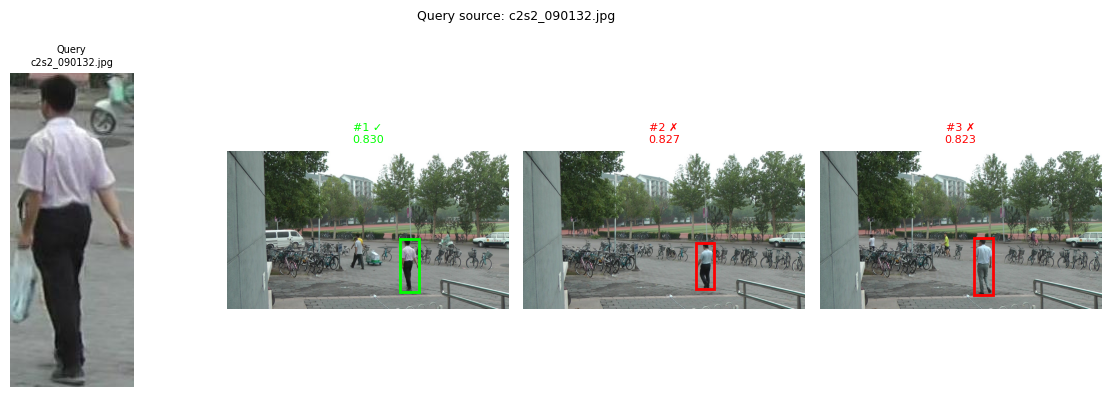

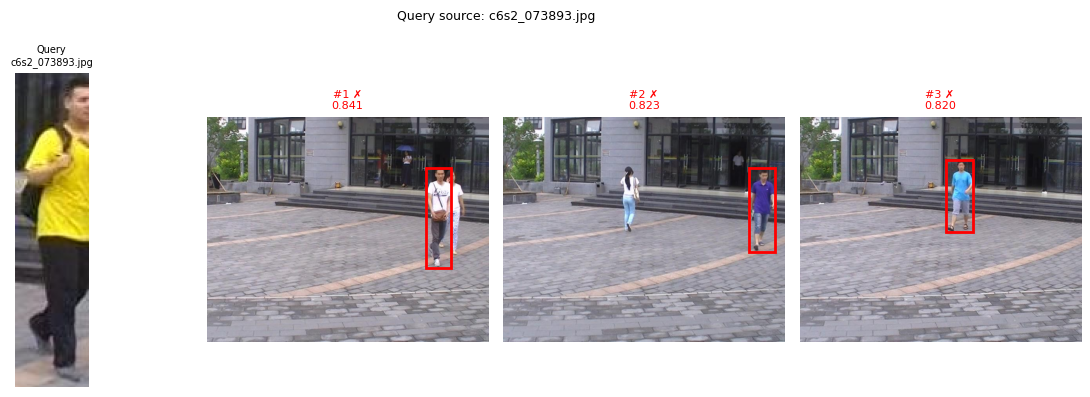

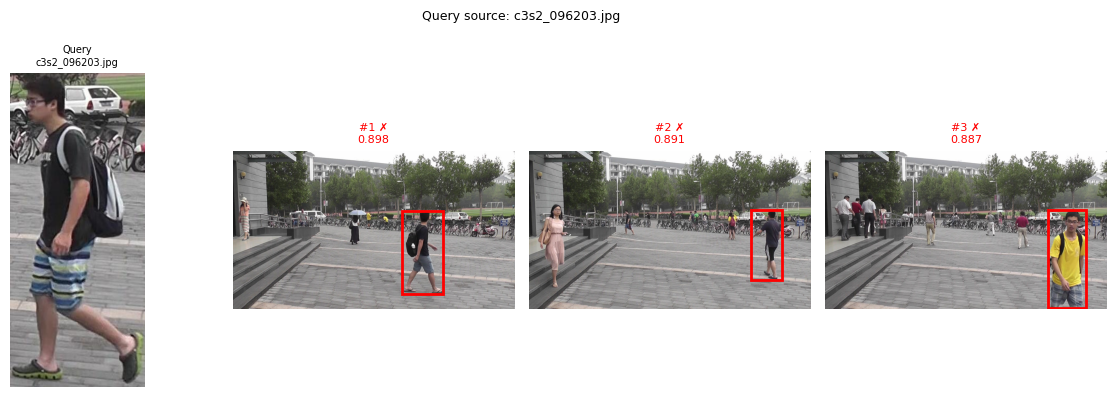

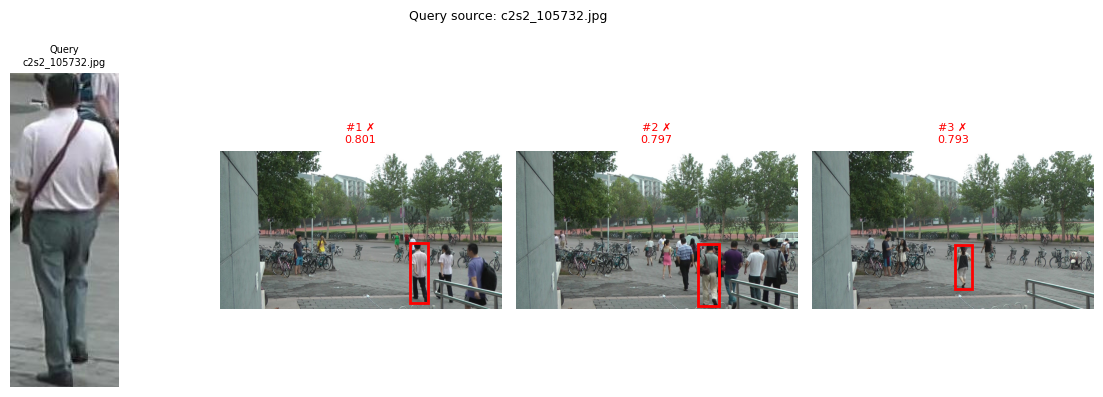

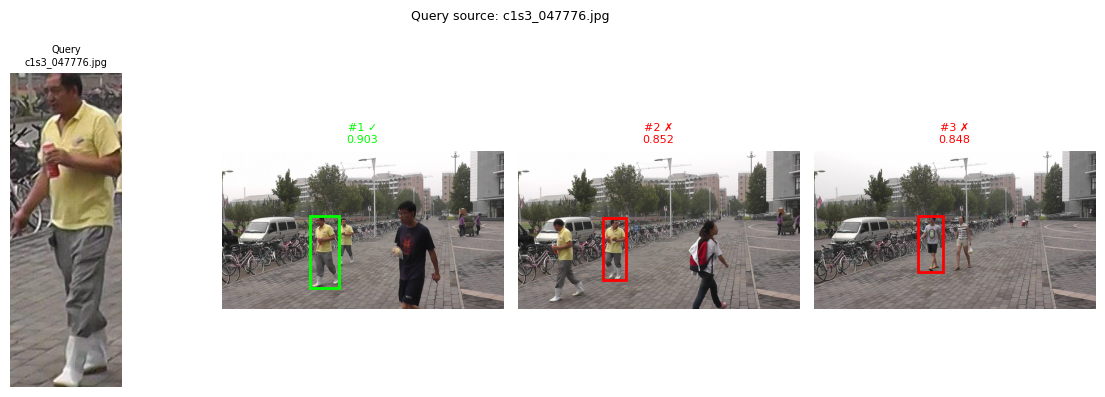

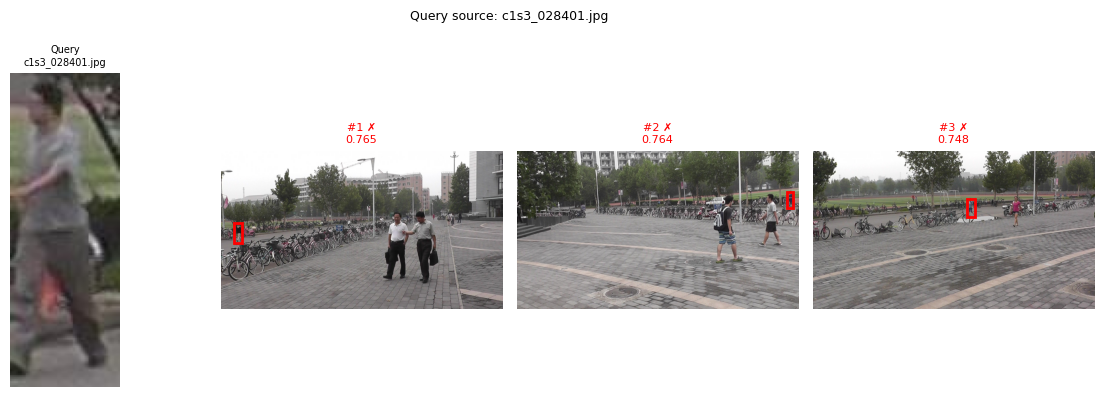

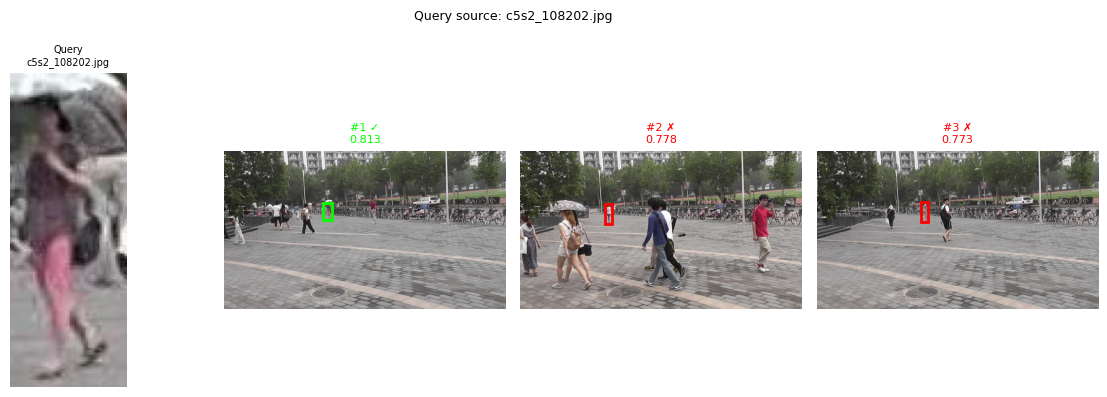

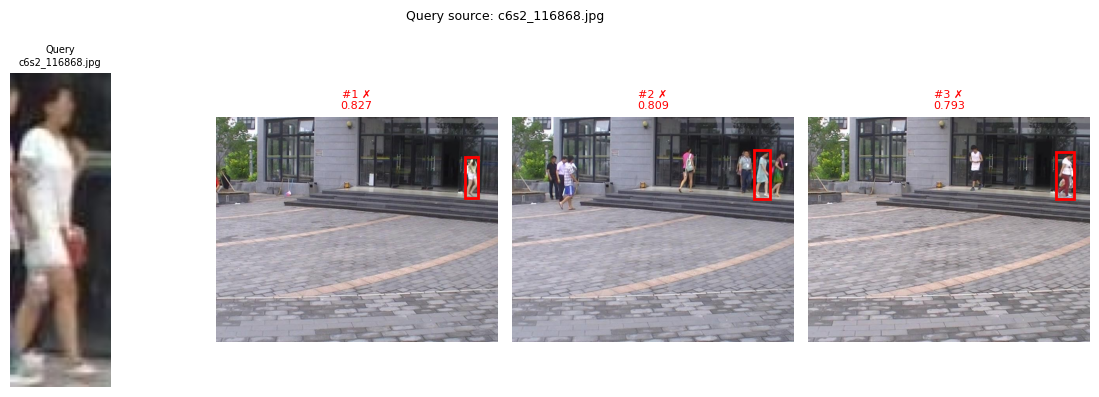

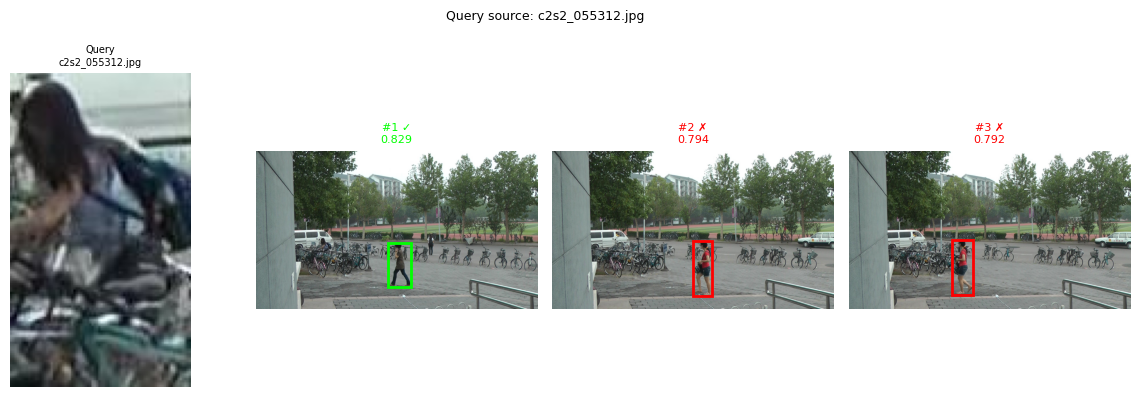

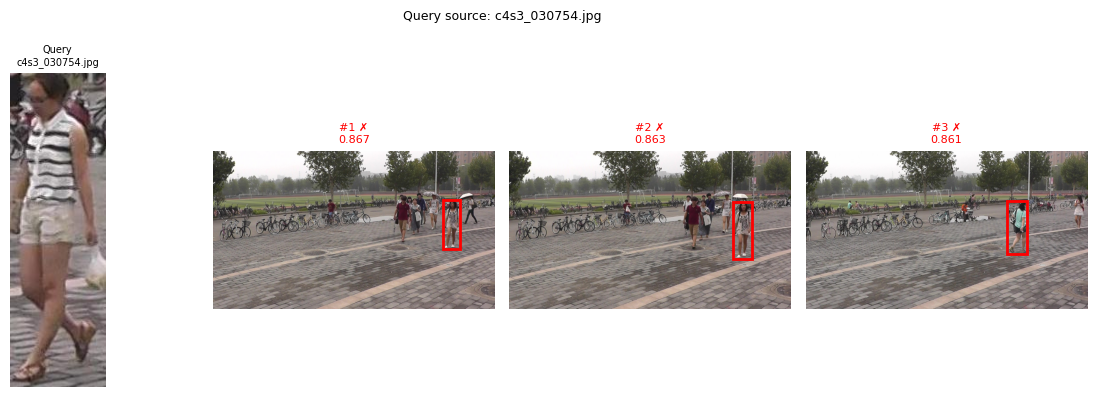

In [25]:
visualize_query_results(results, n_queries=10, top_k=3)